In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('mst-benchmarks.csv')

### MST Graph plots

In [3]:
kruskaldata = df.loc[(df[' NodeCount'] == 5000) & (df['Algorithm'] == 'Kruskal')]
primdata = df.loc[(df[' NodeCount'] == 5000) & (df['Algorithm'] == 'Prim')]
kruskaldata = kruskaldata.drop_duplicates(" EdgeCount")
primdata = primdata.drop_duplicates(" EdgeCount")

In [4]:
primdata

,Algorithm,NodeCount,EdgeCount,Distribution,MeanTime,StdDev,MedianTime
6,Prim,5000,25000,DAG,6.201707,0.502636,6.183511
26,Prim,5000,3124375,DENSE,653.278931,5.164800,651.287105
36,Prim,5000,12497500,COMPLETE,1763.790493,20.972597,1753.958971


In [5]:
kruskaldata

,Algorithm,NodeCount,EdgeCount,Distribution,MeanTime,StdDev,MedianTime
7,Kruskal,5000,25000,DAG,17.414452,1.802063,18.287306
27,Kruskal,5000,3124375,DENSE,1997.706378,34.181299,2006.833733
37,Kruskal,5000,12497500,COMPLETE,8393.265245,53.370518,8407.089919


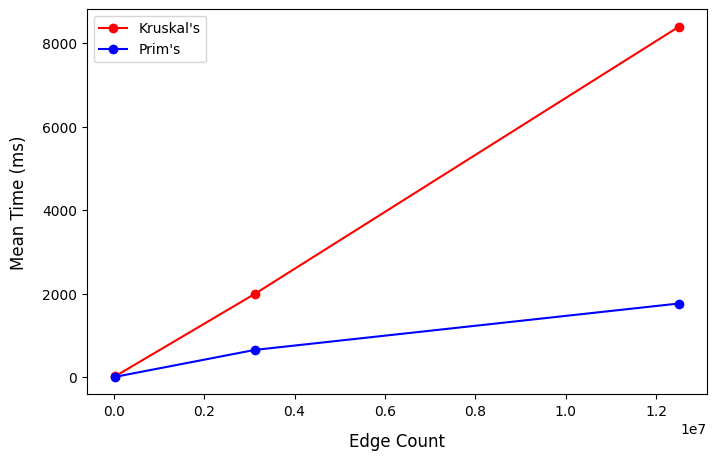

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlabel("Edge Count", fontsize=12, labelpad=10)
ax.set_ylabel("Mean Time (ms)", fontsize=12, labelpad=10)

ax.plot(
    kruskaldata[" EdgeCount"],
    kruskaldata[" MeanTime"],
    marker="o",
    color="red",
    linestyle="-",
    label="Kruskal's",
)
ax.plot(
    primdata[" EdgeCount"],
    primdata[" MeanTime"],
    marker="o",
    color="blue",
    linestyle="-",
    label="Prim's",
)
ax.legend(loc="upper left", fontsize=10, frameon=True)

> **Note that**: The Kruskal's version should run slower on Dense Graph due to the `O(ELgE)` vs `O((V+E)LgV)` however if we disable the pretest-shuffling the caching of sorted list reduces overhead and thus will lead to comparable or even faster faster execution.

## Single Source Shortest Path

In [81]:
df = pd.read_csv('general-sssp-benchmarks.csv')
dijkstradata = df.drop_duplicates(' EdgeCount')
dijkstradata = dijkstradata.sort_values(' EdgeCount')

In [82]:
dijkstradata

,Algorithm,NodeCount,EdgeCount,Distribution,MeanTime,StdDev,MedianTime
0,Dijkstra,1000,5000,DAG,0.490339,0.089441,0.473924
1,Dijkstra,2500,12500,DAG,0.912630,0.068887,0.935206
2,Dijkstra,5000,25000,DAG,3.412446,0.981900,3.278747
3,Dijkstra,7500,37500,DAG,11.491816,3.781458,12.216106
4,Dijkstra,10000,50000,DAG,7.377103,0.547207,7.396751
10,Dijkstra,1000,124875,DENSE,15.097641,3.637077,15.803242
14,Dijkstra,1000,499500,COMPLETE,60.227534,2.676407,61.420612
11,Dijkstra,2500,780937,DENSE,120.992099,13.399004,114.607021
15,Dijkstra,2500,3123750,COMPLETE,201.816966,3.595533,201.064851
12,Dijkstra,5000,3124375,DENSE,361.995898,8.321413,360.048844


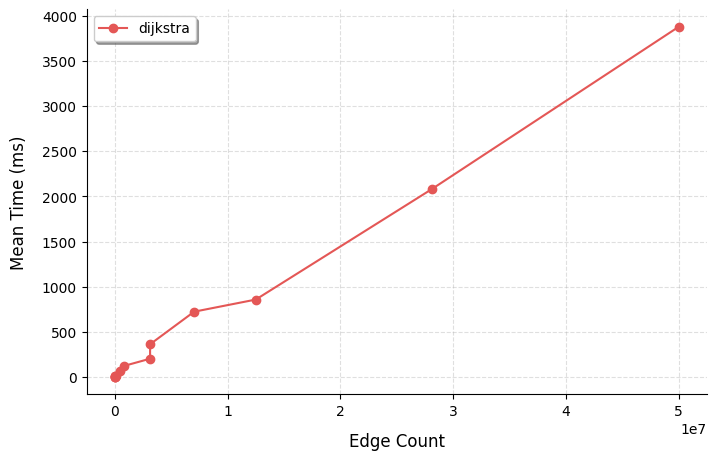

In [83]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlabel("Edge Count", fontsize=12, labelpad=10)
ax.set_ylabel("Mean Time (ms)", fontsize=12, labelpad=10)

ax.plot(
    dijkstradata[" EdgeCount"],
    dijkstradata[" MeanTime"],
    marker="o",
    color="#E45756",
    linestyle="-",
    label="dijkstra",
)

ax.grid(True, linestyle='--', alpha=0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(loc="upper left", 
          fontsize=10, 
          frameon=True,
          fancybox=True,
          shadow=True)

## Dijkstra vs DAG SSSP

In [84]:
# df = pd.read_csv('general-sssp-benchmarks.csv')
# dijkstradata = df.loc[(df[' Distribution'] == ' DAG')]
# dijkstradata = dijkstradata.drop_duplicates(' EdgeCount').sort_values(' EdgeCount')


df = pd.read_csv('dag-sssp-benchmarks.csv')
dagdata = df.loc[(df[ 'Algorithm'] == 'DAG-Topo')]
dagdata = dagdata.drop_duplicates(' EdgeCount').sort_values(' EdgeCount')
# dagdata[' DijkstraMean'] = dagdata[' MeanTime'] * dagdata[' SpeedupMultiplier']

df = pd.read_csv('general-sssp-benchmarks.csv')
dijkstradata = df.loc[(df[' Distribution'] == ' DAG')]
dijkstradata = dijkstradata.drop_duplicates(' EdgeCount').sort_values(' EdgeCount')


In [85]:
dijkstradata

,Algorithm,NodeCount,EdgeCount,Distribution,MeanTime,StdDev,MedianTime
0,Dijkstra,1000,5000,DAG,0.490339,0.089441,0.473924
1,Dijkstra,2500,12500,DAG,0.912630,0.068887,0.935206
2,Dijkstra,5000,25000,DAG,3.412446,0.981900,3.278747
3,Dijkstra,7500,37500,DAG,11.491816,3.781458,12.216106
4,Dijkstra,10000,50000,DAG,7.377103,0.547207,7.396751


In [86]:
dagdata

,Algorithm,NodeCount,EdgeCount,MeanTime,StdDev,MedianTime,SpeedupMultiplier
0,DAG-Topo,1000,5000,0.270537,0.004341,0.268919,0.637163
1,DAG-Topo,2500,12500,0.637351,0.009977,0.636413,0.476061
2,DAG-Topo,5000,25000,1.180123,0.152606,1.121936,2.159342
3,DAG-Topo,7500,37500,1.672705,0.076051,1.649056,1.091701
4,DAG-Topo,10000,50000,2.311793,0.086025,2.311638,1.615233


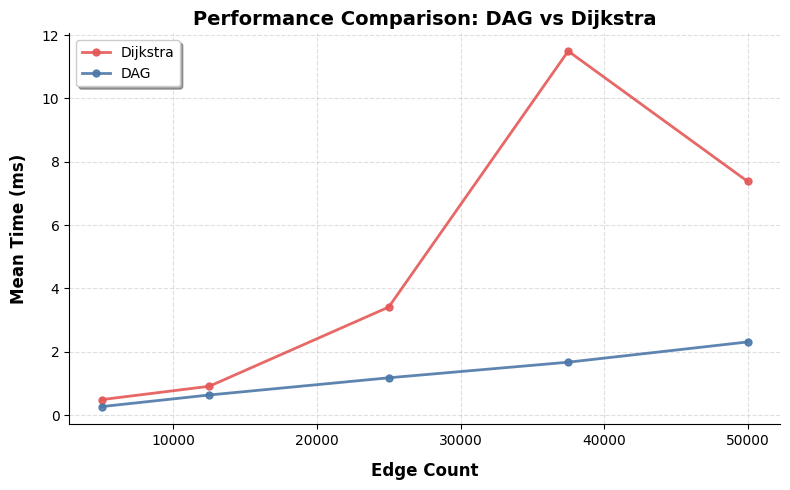

In [87]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    dijkstradata[" EdgeCount"],
    dijkstradata[" MeanTime"],
    marker="o",
    markersize=5,
    linewidth=2,
    color="#E45756",
    label="Dijkstra",
    alpha=0.9,
)

ax.plot(
    dagdata[" EdgeCount"],
    dagdata[" MeanTime"],
    marker="o",
    markersize=5,
    linewidth=2,
    color="#4C78A8",
    label="DAG",
    alpha=0.9,
)


ax.set_xlabel("Edge Count", fontsize=12, fontweight="bold", labelpad=10)
ax.set_ylabel("Mean Time (ms)", fontsize=12, fontweight="bold", labelpad=10)
ax.set_title("Performance Comparison: DAG vs Dijkstra", fontsize=14, fontweight="bold")


ax.grid(True, linestyle="--", alpha=0.4)

ax.legend(
    loc="upper left",
    fontsize=10,
    frameon=True,
    fancybox=True,
    shadow=True
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

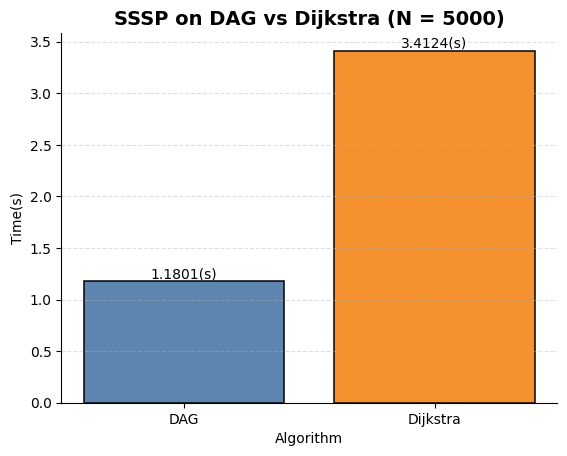

In [88]:
fig, ax = plt.subplots()
dijkstratime = dijkstradata.loc[
    (dijkstradata[' NodeCount'] == 5000) &
    (dijkstradata[' Distribution'] == ' DAG')
][' MeanTime'].iloc[0]

dagtime = dagdata.loc[
    dagdata[' NodeCount'] == 5000
][' MeanTime'].iloc[0]

y = [dagtime, dijkstratime]
x = ["DAG", "Dijkstra"]

bars = ax.bar(
    x, y,
    color=["#4C78A8", "#F58518"],  
    edgecolor="black",
    linewidth=1.2,
    alpha=0.9
)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.4f}(s)",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_ylabel("Time(s)")
ax.set_xlabel("Algorithm")
ax.grid(axis="y", linestyle="--", alpha=0.4)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("SSSP on DAG vs Dijkstra (N = 5000)", fontsize=14, fontweight="bold")

plt.show()
